# Bike Sharing System - Core Domain Model

✅ PlantUML source saved to bike_rental_system.puml
✅ Diagram saved to bike_rental_system.png


## Bike Rental System Class Diagram

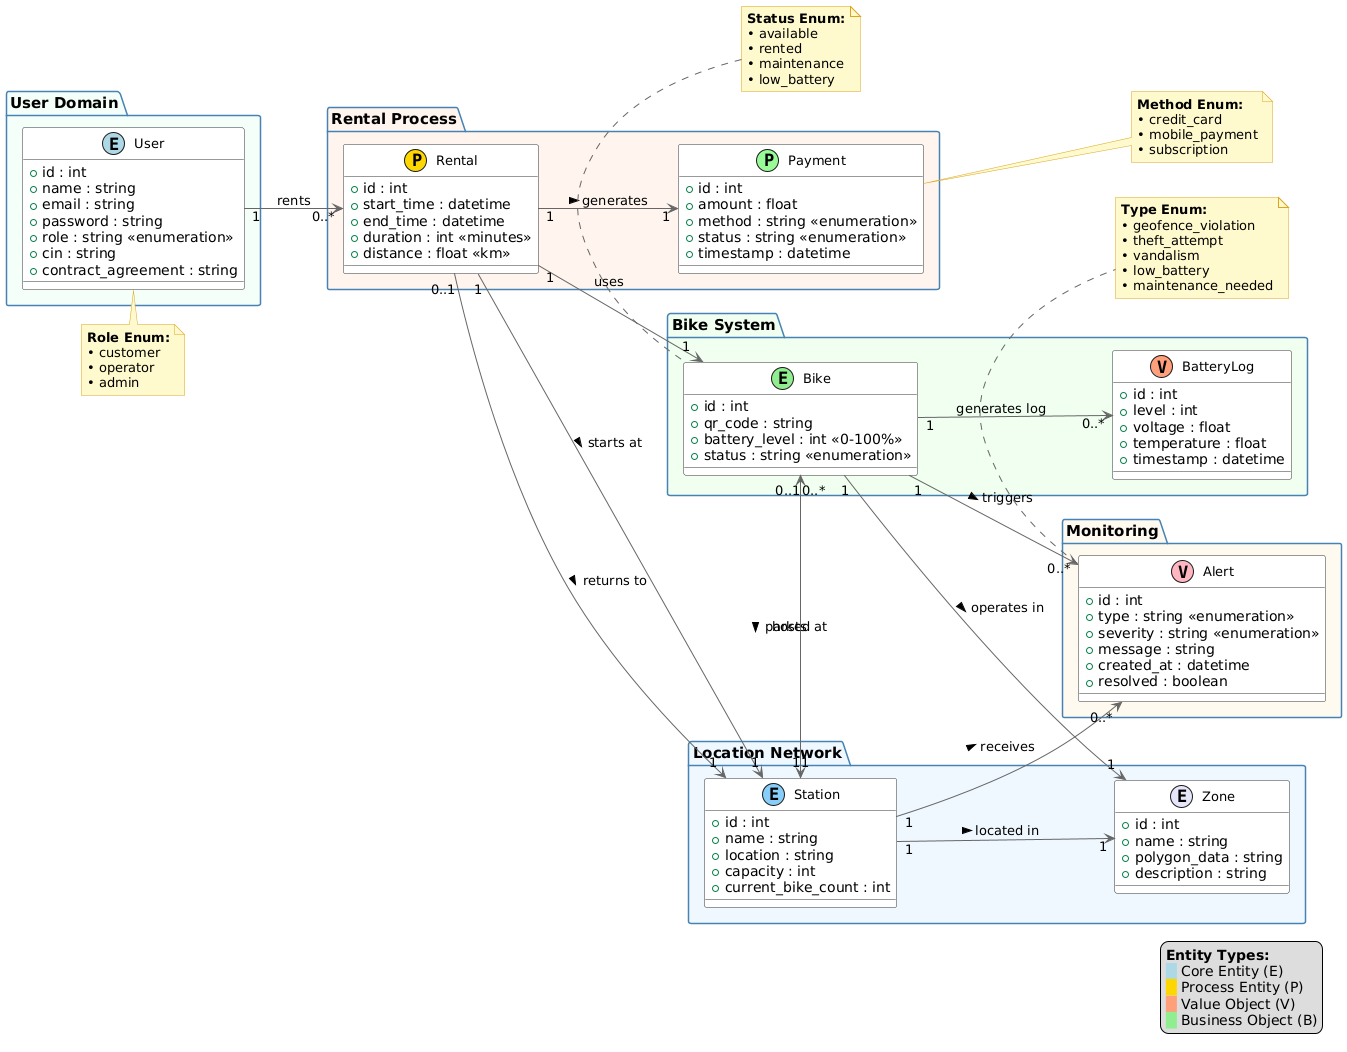

In [70]:
from plantuml import PlantUML
from IPython.display import Image, display, Markdown
import requests

# Initialize PlantUML server connection
server = PlantUML(url='http://www.plantuml.com/plantuml/img/')

# Your UML diagram code
uml_code = """
@startuml

' ==== Configuration ====
left to right direction
skinparam class {
  BackgroundColor White
  BorderColor #333
  ArrowColor #666
  FontSize 13
}
skinparam package {
  BackgroundColor #F0F8FF
  BorderColor #4682B4
  FontSize 15
  FontStyle bold
}
skinparam note {
  BackgroundColor #FFFACD
  BorderColor #DAA520
}

' ==== Core Entities ====
package "User Domain" #F5FFFA {
  class User <<(E,#ADD8E6)>> {
    +id : int
    +name : string
    +email : string
    +password : string
    +role : string <<enumeration>>
    +cin : string
    +contract_agreement : string
  }
}

package "Rental Process" #FFF5EE {
  class Rental <<(P,#FFD700)>> {
    +id : int
    +start_time : datetime
    +end_time : datetime
    +duration : int <<minutes>>
    +distance : float <<km>>
  }
  
  class Payment <<(P,#98FB98)>> {
    +id : int
    +amount : float
    +method : string <<enumeration>>
    +status : string <<enumeration>>
    +timestamp : datetime
  }
}

package "Bike System" #F0FFF0 {
  class Bike <<(E,#90EE90)>> {
    +id : int
    +qr_code : string
    +battery_level : int <<0-100%>>
    +status : string <<enumeration>>
  }
  
  class BatteryLog <<(V,#FFA07A)>> {
    +id : int
    +level : int
    +voltage : float
    +temperature : float
    +timestamp : datetime
  }
}

package "Location Network" #F0F8FF {
  class Station <<(E,#87CEFA)>> {
    +id : int
    +name : string
    +location : string
    +capacity : int
    +current_bike_count : int
  }
  
  class Zone <<(E,#E6E6FA)>> {
    +id : int
    +name : string
    +polygon_data : string
    +description : string
  }
}

package "Monitoring" #FFFAF0 {
  class Alert <<(V,#FFB6C1)>> {
    +id : int
    +type : string <<enumeration>>
    +severity : string <<enumeration>>
    +message : string
    +created_at : datetime
    +resolved : boolean
  }
}

' ==== Relationships ====
User "1" --> "0..*" Rental : "rents"
Rental "1" --> "1" Bike : "uses"
Rental "1" --> "1" Payment : "generates >"
Rental "1" --> "1" Station : "starts at >"
Rental "0..1" --> "1" Station : "returns to >"

Bike "1" --> "0..*" BatteryLog : "generates log"
Bike "1" --> "0..*" Alert : "triggers >"
Bike "0..1" --> "1" Station : "parked at >"
Bike "1" --> "1" Zone : "operates in >"

Station "1" --> "0..*" Bike : "hosts"
Station "1" --> "0..*" Alert : "receives >"
Station "1" --> "1" Zone : "located in >"

' ==== Enumeration Notes ====
note top of User
  <b>Role Enum:</b>
  • customer
  • operator
  • admin
end note

note top of Bike
  <b>Status Enum:</b>
  • available
  • rented
  • maintenance
  • low_battery
end note

note right of Payment
  <b>Method Enum:</b>
  • credit_card
  • mobile_payment
  • subscription
end note

note bottom of Alert
  <b>Type Enum:</b>
  • geofence_violation
  • theft_attempt
  • vandalism
  • low_battery
  • maintenance_needed
end note

' ==== Legend ====
legend right
  <b>Entity Types:</b>
  <color:#ADD8E6>█</color> Core Entity (E)
  <color:#FFD700>█</color> Process Entity (P)
  <color:#FFA07A>█</color> Value Object (V)
  <color:#90EE90>█</color> Business Object (B)
end legend

@enduml
"""

# 1. Save PlantUML source code
with open("bike_rental_system.puml", "w") as f:
    f.write(uml_code)
print("✅ PlantUML source saved to bike_rental_system.puml")

# 2. Generate and save diagram image
try:
    # Option A: Using requests (for PNG)
    image_url = server.get_url(uml_code)
    response = requests.get(image_url)
    response.raise_for_status()
    
    with open("bike_rental_system.png", "wb") as f:
        f.write(response.content)
    print("✅ Diagram saved to bike_rental_system.png")
    
    # Option B: Direct binary save (alternative)
    # with open("bike_rental_system.png", "wb") as f:
    #     f.write(server.processes(uml_code))
    
    # Display in notebook
    display(Markdown("## Bike Rental System Class Diagram"))
    display(Image(filename="bike_rental_system.png"))
    
except Exception as e:
    print(f"❌ Error generating diagram: {str(e)}")
    print("Troubleshooting tips:")
    print("1. Check internet connection")
    print("2. Try a local PlantUML server:")
    print("   docker run -d -p 8080:8080 plantuml/plantuml-server")
    print("3. Test your diagram at http://www.plantuml.com/plantuml")

# Bike Sharing System - Operational Workflows

## 1. User Registration

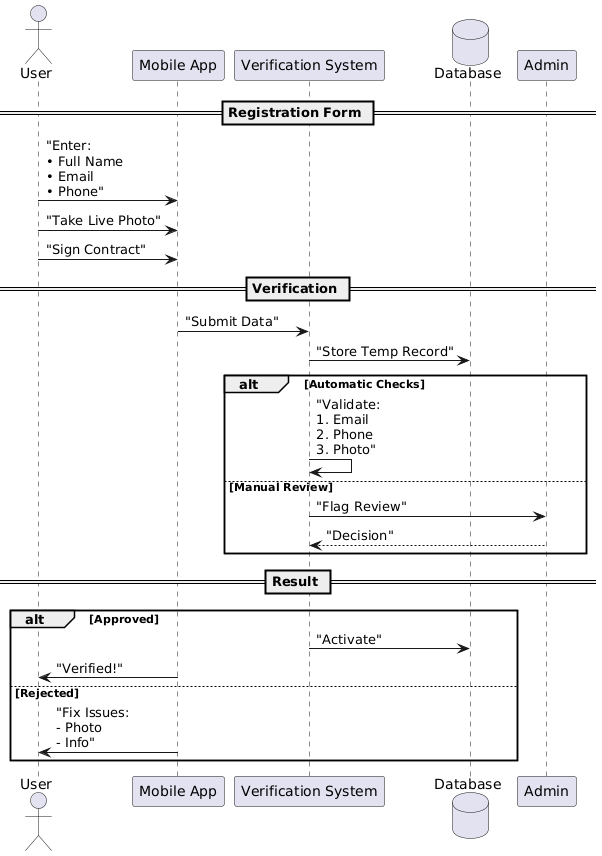

✅ **Saved to**:
- `diagrams/puml/user_registration.puml`
- `diagrams/png/user_registration.png`

## 2. Normal Rental Flow

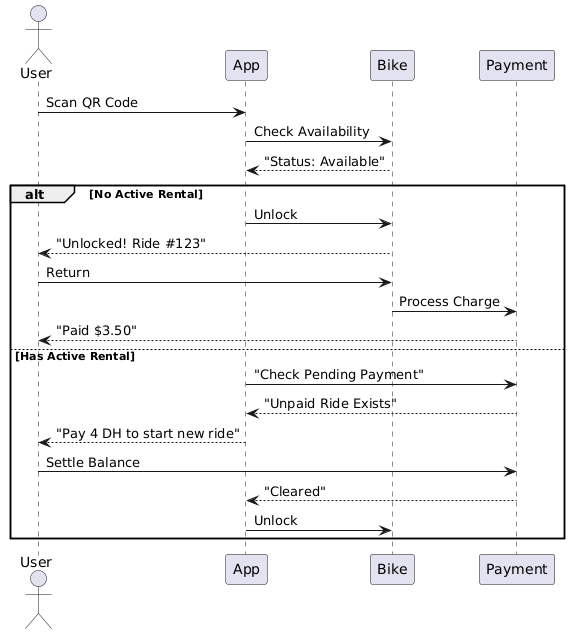

✅ **Saved to**:
- `diagrams/puml/normal_rental_flow.puml`
- `diagrams/png/normal_rental_flow.png`

## 3. Geofence Violation

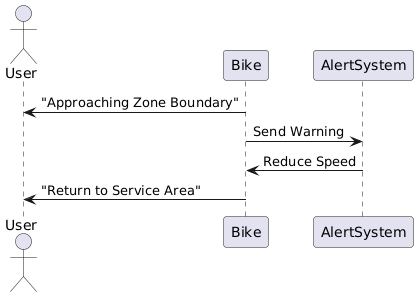

✅ **Saved to**:
- `diagrams/puml/geofence_violation.puml`
- `diagrams/png/geofence_violation.png`

## 4. Low Battery Protocol

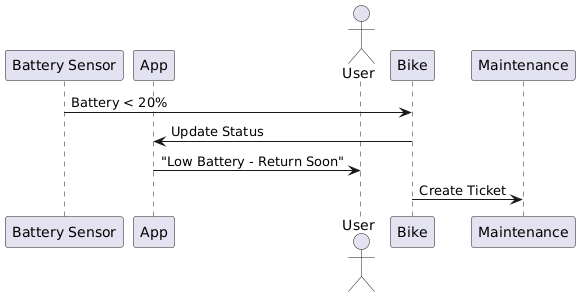

✅ **Saved to**:
- `diagrams/puml/low_battery_protocol.puml`
- `diagrams/png/low_battery_protocol.png`

## 5. Theft Attempt Handling

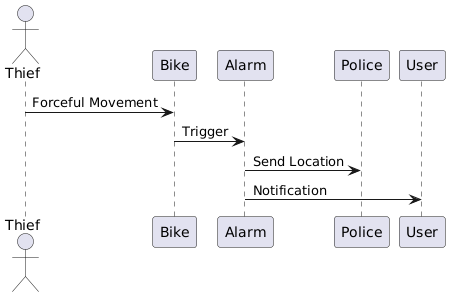

✅ **Saved to**:
- `diagrams/puml/theft_attempt_handling.puml`
- `diagrams/png/theft_attempt_handling.png`

## 6. Payment Failure

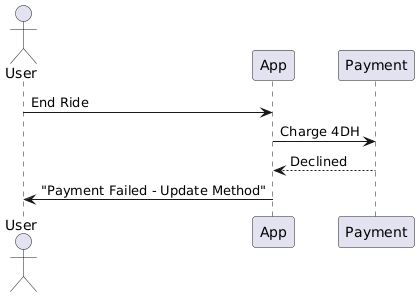

✅ **Saved to**:
- `diagrams/puml/payment_failure.puml`
- `diagrams/png/payment_failure.png`

## 7. Multi-Bike Rent Block

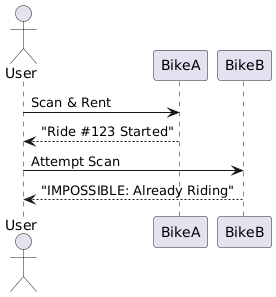

✅ **Saved to**:
- `diagrams/puml/multibike_rent_block.puml`
- `diagrams/png/multibike_rent_block.png`

## 8. Multi-User Scan Block

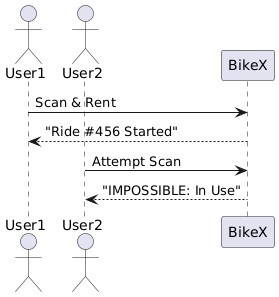

✅ **Saved to**:
- `diagrams/puml/multiuser_scan_block.puml`
- `diagrams/png/multiuser_scan_block.png`

## 9. Emergency Stop

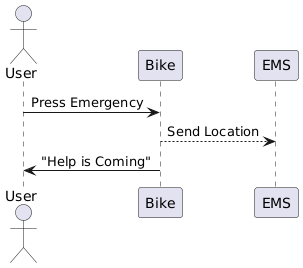

✅ **Saved to**:
- `diagrams/puml/emergency_stop.puml`
- `diagrams/png/emergency_stop.png`

NameError: name 'shutil' is not defined

In [73]:
from plantuml import PlantUML
from IPython.display import Image, display, Markdown
import os

# Initialize PlantUML server
server = PlantUML(url='http://www.plantuml.com/plantuml/img/')

# Create output directories if they don't exist
# Create output directories with full paths
base_dir = "diagrams"
os.makedirs(os.path.join(base_dir, "puml"), exist_ok=True)
os.makedirs(os.path.join(base_dir, "png"), exist_ok=True)

# All scenarios with validated PlantUML syntax
scenarios = {

    # =============  USER REGISTRATION =============
    "1. User Registration": """
@startuml

actor User
participant "Mobile App" as App
participant "Verification System" as System
database "Database"

== Registration Form ==
User -> App: "Enter: \\n• Full Name\\n• Email\\n• Phone"
User -> App: "Take Live Photo"
User -> App: "Sign Contract"

== Verification ==
App -> System: "Submit Data"
System -> Database: "Store Temp Record"

alt Automatic Checks
    System -> System: "Validate:\\n1. Email\\n2. Phone\\n3. Photo"
else Manual Review
    System -> "Admin": "Flag Review"
    "Admin" --> System: "Decision"
end

== Result ==
alt Approved
    System -> Database: "Activate"
    App -> User: "Verified!"
else Rejected
    App -> User: "Fix Issues:\\n- Photo\\n- Info"
end
@enduml
""",  # MUST be on same line
    # ============= CORE USER FLOWS =============
    "2. Normal Rental Flow": """@startuml
actor User
participant App
participant Bike
participant Payment

User -> App: Scan QR Code
App -> Bike: Check Availability
Bike --> App: "Status: Available"

alt No Active Rental
    App -> Bike: Unlock
    Bike --> User: "Unlocked! Ride #123"
    User -> Bike: Return
    Bike -> Payment: Process Charge
    Payment --> User: "Paid $3.50"
else Has Active Rental
    App -> Payment: "Check Pending Payment"
    Payment --> App: "Unpaid Ride Exists"
    App --> User: "Pay 4 DH to start new ride"
    User -> Payment: Settle Balance
    Payment --> App: "Cleared"
    App -> Bike: Unlock
end
@enduml
""",

    # ============= SAFETY & ALERTS =============
    "3. Geofence Violation": """
@startuml
actor User
participant Bike
participant AlertSystem

Bike -> User: "Approaching Zone Boundary"
Bike -> AlertSystem: Send Warning
AlertSystem -> Bike: Reduce Speed
Bike -> User: "Return to Service Area"
@enduml
""",

    "4. Low Battery Protocol": """
@startuml
participant "Battery Sensor" as Sensor
participant App
actor User

Sensor -> Bike: Battery < 20%
Bike -> App: Update Status
App -> User: "Low Battery - Return Soon"
Bike -> Maintenance: Create Ticket
@enduml
""",

    "5. Theft Attempt Handling": """
@startuml
actor Thief
participant Bike
participant Alarm

Thief -> Bike: Forceful Movement
Bike -> Alarm: Trigger
Alarm -> Police: Send Location
Alarm -> User: Notification
@enduml
""",

    # ============= PAYMENT FLOWS =============
    "6. Payment Failure": """
@startuml
actor User
participant App
participant Payment

User -> App: End Ride
App -> Payment: Charge 4DH
Payment --> App: Declined
App -> User: "Payment Failed - Update Method"
@enduml
""",

    # ============= MULTI-USER PROTECTION =============
    "7. Multi-Bike Rent Block": """
@startuml
actor User
participant BikeA
participant BikeB

User -> BikeA: Scan & Rent
BikeA --> User: "Ride #123 Started"
User -> BikeB: Attempt Scan
BikeB --> User: "IMPOSSIBLE: Already Riding"
@enduml
""",

    "8. Multi-User Scan Block": """
@startuml
actor User1
actor User2
participant BikeX

User1 -> BikeX: Scan & Rent
BikeX --> User1: "Ride #456 Started"
User2 -> BikeX: Attempt Scan
BikeX --> User2: "IMPOSSIBLE: In Use"
@enduml
""",

    # ============= EMERGENCY FLOWS =============
    "9. Emergency Stop": """
@startuml
actor User
participant Bike

User -> Bike: Press Emergency
Bike --> EMS: Send Location
Bike -> User: "Help is Coming"
@enduml
""",


}

# Generate all diagrams with error handling
# Process all scenarios
for name, diagram in scenarios.items():
    # Clean filename (remove numbering and special chars)
    clean_name = "".join(c for c in name.split(".")[-1].strip() if c.isalnum() or c in (" ", "_"))
    filename_base = clean_name.replace(' ', '_').lower()
    
    try:
        # 1. Save PlantUML source
        puml_path = os.path.join(base_dir, "puml", f"{filename_base}.puml")
        with open(puml_path, "w") as f:
            f.write(diagram)
        
        # 2. Generate and save PNG
        png_path = os.path.join(base_dir, "png", f"{filename_base}.png")
        
        # Method A: Using requests (recommended)
        image_url = server.get_url(diagram)
        response = requests.get(image_url)
        response.raise_for_status()
        
        with open(png_path, "wb") as f:
            f.write(response.content)
        
        # Display in notebook
        display(Markdown(f"## {name}"))
        display(Image(filename=png_path))
        display(Markdown(f"✅ **Saved to**:\n- `{puml_path}`\n- `{png_path}`"))
        
    except Exception as e:
        display(Markdown(f"❌ **Error in {name}**: {str(e)}"))
        display(Markdown("```plantuml\n" + diagram + "\n```"))
        display(Markdown("**Troubleshooting**:\n"
                       "1. Check directory permissions\n"
                       "2. Verify internet connection\n"
                       "3. Test diagram at [web editor](http://www.plantuml.com/plantuml)"))

# Zip all diagrams
shutil.make_archive("bike_scenarios", 'zip', base_dir)
display(Markdown("📦 **All diagrams zipped as**: `bike_scenarios.zip`"))



## 01 Database Schema

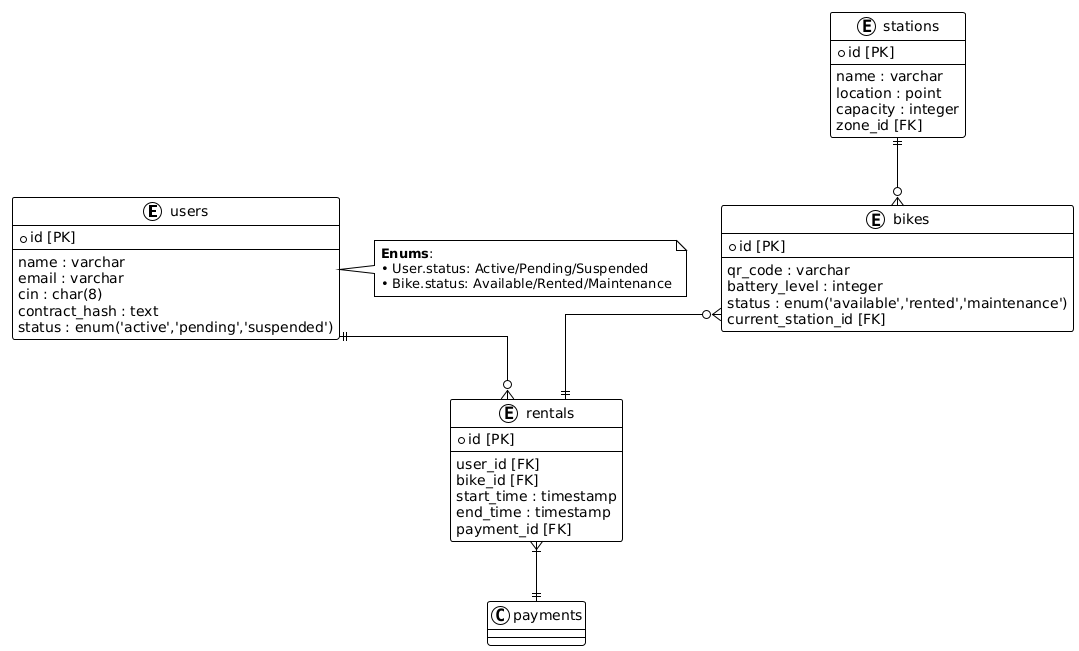

✅ Saved to: `saved_diagrams/01_database_schema.png`


## 02 Class Diagram

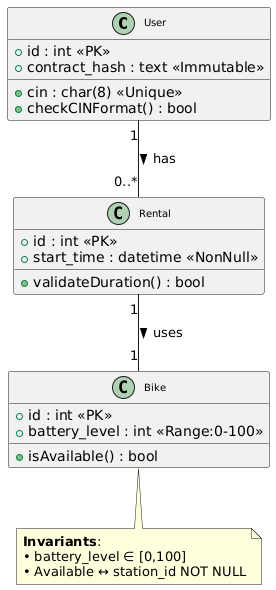

✅ Saved to: `saved_diagrams/02_class_diagram.png`


## 03 Component Diagram

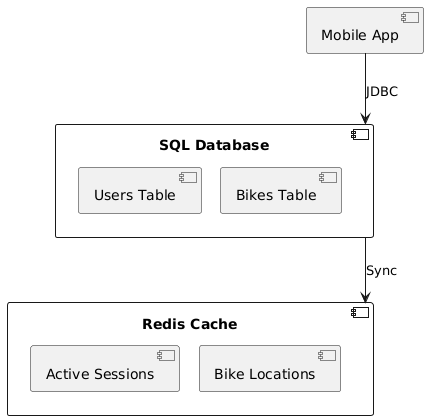

✅ Saved to: `saved_diagrams/03_component_diagram.png`


📦 **All diagrams zipped as**: `system_diagrams.zip`

In [74]:
from plantuml import PlantUML
from IPython.display import Image, display, Markdown
import os
import requests

# Initialize PlantUML server
server = PlantUML(url='http://www.plantuml.com/plantuml/img/')

# Create output directory if it doesn't exist
os.makedirs("saved_diagrams", exist_ok=True)

# 1. Database Schema Diagram
db_schema = """
@startuml
!theme plain
top to bottom direction

skinparam linetype ortho

entity "users" {
  + id [PK]
  --
  name : varchar
  email : varchar
  cin : char(8)
  contract_hash : text
  status : enum('active','pending','suspended')
}

entity "bikes" {
  + id [PK]
  --
  qr_code : varchar
  battery_level : integer
  status : enum('available','rented','maintenance')
  current_station_id [FK]
}

entity "stations" {
  + id [PK]
  --
  name : varchar
  location : point
  capacity : integer
  zone_id [FK]
}

entity "rentals" {
  + id [PK]
  --
  user_id [FK]
  bike_id [FK]
  start_time : timestamp
  end_time : timestamp
  payment_id [FK]
}

users ||--o{ rentals
bikes }o--|| rentals
stations ||--o{ bikes
rentals }|--|| payments

note right of users
  **Enums**:
  • User.status: Active/Pending/Suspended
  • Bike.status: Available/Rented/Maintenance
end note
@enduml
"""

# 2. Class Diagram with Constraints
class_diagram = """
@startuml
skinparam classFontSize 10

class User {
  +id : int <<PK>>
  +cin : char(8) <<Unique>>
  +contract_hash : text <<Immutable>>
  +checkCINFormat() : bool
}

class Bike {
  +id : int <<PK>>
  +battery_level : int <<Range:0-100>>
  +isAvailable() : bool
}

class Rental {
  +id : int <<PK>>
  +start_time : datetime <<NonNull>>
  +validateDuration() : bool
}

User "1" -- "0..*" Rental : has >
Rental "1" -- "1" Bike : uses >

note bottom of Bike
  **Invariants**:
  • battery_level ∈ [0,100]
  • Available ↔ station_id NOT NULL
end note
@enduml
"""

# 3. Component Diagram
component_diagram = """
@startuml
skinparam nodesep 20

component "SQL Database" {
  [Users Table]
  [Bikes Table]
}

component "Redis Cache" {
  [Active Sessions]
  [Bike Locations]
}

[Mobile App] --> [SQL Database] : JDBC
[SQL Database] --> [Redis Cache] : Sync
@enduml
"""

# Dictionary of all diagrams
diagrams = {
    "01_database_schema": db_schema,
    "02_class_diagram": class_diagram,
    "03_component_diagram": component_diagram
}

# Process and save all diagrams
for filename, diagram in diagrams.items():
    try:
        # Generate image URL
        image_url = server.get_url(diagram)
        
        # Download and save the image
        response = requests.get(image_url)
        response.raise_for_status()
        
        # Save to file
        png_path = f"saved_diagrams/{filename}.png"
        with open(png_path, "wb") as f:
            f.write(response.content)
        
        # Display in notebook
        display(Markdown(f"## {filename.replace('_', ' ').title()}"))
        display(Image(filename=png_path))
        display(Markdown(f"✅ Saved to: `{png_path}`\n"))
        
    except Exception as e:
        display(Markdown(f"❌ Error saving {filename}: {str(e)}"))
        display(Markdown("```plantuml\n" + diagram + "\n```"))

# Create zip archive of all diagrams
import shutil
shutil.make_archive("system_diagrams", 'zip', "saved_diagrams")
display(Markdown("📦 **All diagrams zipped as**: `system_diagrams.zip`"))

## Production-Ready Bike Lifecycle

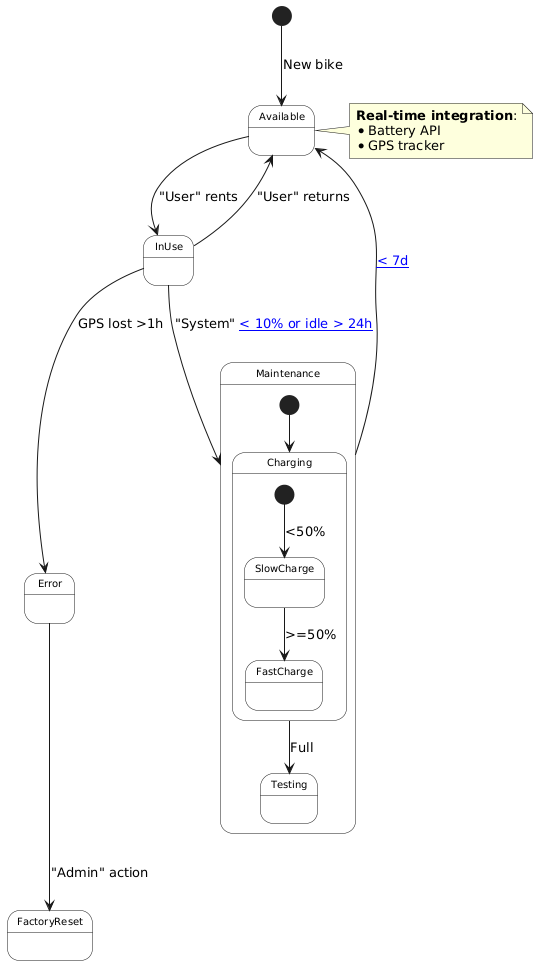

✅ Diagram saved to: `saved_diagrams/bike_lifecycle_state_diagram.png`

📦 All diagrams zipped as: `bike_diagrams.zip`

In [75]:
from plantuml import PlantUML
from IPython.display import Image, display, Markdown
import os
import requests

# Initialize PlantUML server
server = PlantUML(url='http://www.plantuml.com/plantuml/img/')

# Create output directory if it doesn't exist
os.makedirs("saved_diagrams", exist_ok=True)

# State diagram definition
state_diagram = r"""
@startuml
skinparam stateFontSize 10
skinparam state {
  BackgroundColor Available<<Available>> LightGreen
  BackgroundColor Maintenance<<Maintenance>> Gold
  BackgroundColor Error<<Error>> #FFDDDD
  FontName Arial
}

[*] --> Available : New bike
Available --> InUse : "User" rents
InUse --> Available : "User" returns
InUse --> Maintenance : "System" [[battery < 10% or idle > 24h]]
Maintenance --> Available : [[last_checked < 7d]]
InUse --> Error : GPS lost >1h
Error --> FactoryReset : "Admin" action

state Maintenance {
  [*] --> Charging
  state Charging {
    [*] --> SlowCharge : <50%
    SlowCharge --> FastCharge : >=50%
  }
  Charging --> Testing : Full
}

note right of Available
  <b>Real-time integration</b>:
  * Battery API
  * GPS tracker
end note
@enduml
"""

try:
    # Generate image URL
    image_url = server.get_url(state_diagram)
    
    # Save diagram as PNG
    png_path = "saved_diagrams/bike_lifecycle_state_diagram.png"
    response = requests.get(image_url)
    response.raise_for_status()
    
    with open(png_path, "wb") as f:
        f.write(response.content)
    
    # Display in notebook
    display(Markdown("## Production-Ready Bike Lifecycle"))
    display(Image(filename=png_path, width=800))
    display(Markdown(f"✅ Diagram saved to: `{png_path}`"))
    
except Exception as e:
    display(Markdown(f"❌ Error generating diagram: {str(e)}"))
    display(Markdown("```plantuml\n" + state_diagram + "\n```"))
    display(Markdown("**Troubleshooting steps:**\n"
                   "1. Check your internet connection\n"
                   "2. Try the diagram at [PlantUML Web Server](http://www.plantuml.com/plantuml)\n"
                   "3. Run a local server: `docker run -d -p 8080:8080 plantuml/plantuml-server`"))

# Optional: Create zip archive
import shutil
shutil.make_archive("bike_diagrams", 'zip', "saved_diagrams")
display(Markdown("📦 All diagrams zipped as: `bike_diagrams.zip`"))

## Bike System Integration with Alerts

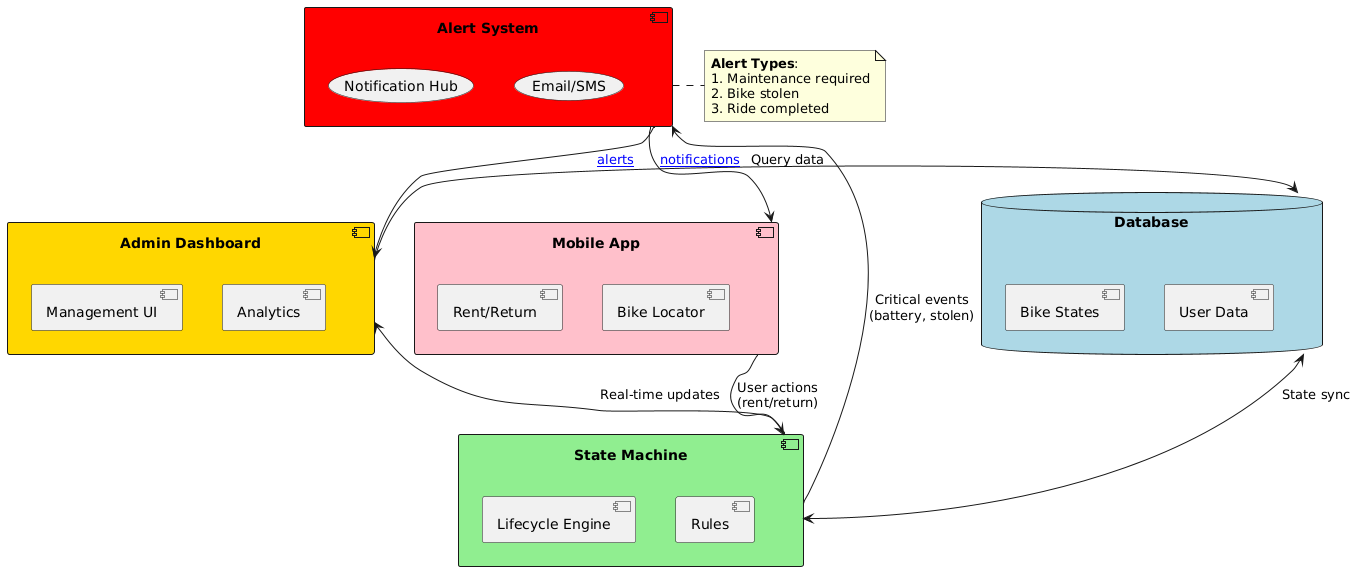

✅ Diagram saved to: `saved_diagrams/alert_system_diagram.png`

📦 All diagrams zipped as: `system_diagrams.zip`

In [76]:
from plantuml import PlantUML
from IPython.display import Image, display, Markdown
import os
import requests

# Initialize PlantUML server
server = PlantUML(url='http://www.plantuml.com/plantuml/img/')

# Create output directory if it doesn't exist
os.makedirs("saved_diagrams", exist_ok=True)

# Alert system diagram definition
alert_diagram = r"""
@startuml
skinparam monochrome false
skinparam defaultFontName Arial
skinparam nodesep 40
skinparam ranksep 60

database "Database" as db #LightBlue {
  [Bike States]
  [User Data]
}

component "State Machine" as fsm #LightGreen {
  [Lifecycle Engine]
  [Rules]
}

component "Admin Dashboard" as admin #Gold {
  [Management UI]
  [Analytics]
}

component "Mobile App" as app #Pink {
  [Rent/Return]
  [Bike Locator]
}

component "Alert System" as alerts #Red {
  (Notification Hub)
  (Email/SMS)
}

' Core Data Flows
db <--> fsm : State sync
fsm --> admin : Real-time updates
admin --> db : Query data
app --> fsm : User actions\n(rent/return)

' Alert Flows
fsm --> alerts : Critical events\n(battery, stolen)
alerts --> admin : [[Dashboard alerts]]
alerts --> app : [[Push notifications]]

note right of alerts
  <b>Alert Types</b>:
  1. Maintenance required
  2. Bike stolen
  3. Ride completed
end note
@enduml
"""

try:
    # Generate image URL
    image_url = server.get_url(alert_diagram)
    
    # Save diagram as PNG
    png_path = "saved_diagrams/alert_system_diagram.png"
    response = requests.get(image_url)
    response.raise_for_status()
    
    with open(png_path, "wb") as f:
        f.write(response.content)
    
    # Display in notebook
    display(Markdown("## Bike System Integration with Alerts"))
    display(Image(filename=png_path))
    display(Markdown(f"✅ Diagram saved to: `{png_path}`"))
    
except Exception as e:
    display(Markdown(f"❌ Error generating diagram: {str(e)}"))
    display(Markdown("```plantuml\n" + alert_diagram + "\n```"))
    display(Markdown("**Troubleshooting steps:**\n"
                   "1. Check your internet connection\n"
                   "2. Verify the PlantUML syntax at [web editor](http://www.plantuml.com/plantuml)\n"
                   "3. Try a local server: `docker run -d -p 8080:8080 plantuml/plantuml-server`"))

# Optional: Create zip archive of all saved diagrams
import shutil
shutil.make_archive("system_diagrams", 'zip', "saved_diagrams")
display(Markdown("📦 All diagrams zipped as: `system_diagrams.zip`"))

Copyright Younes Sghyer